# Student Pass/Fail Prediction — Model Building & Evaluation

Trains 7 classifiers, runs cross-validation, plots ROC curves, tunes the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, f1_score

from utils import (
    evaluate_model, plot_confusion_matrix, plot_roc_curves,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/student_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (1044, 49)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,course_portuguese,AgeGroup_17,AgeGroup_18,AgeGroup_19+
0,18,4,4,2,2,0,4,3,4,1,...,0,0,1,1,0,0,0,0,1,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,1,0,0,1,0,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,1,1,1,0,0,0,0,0
3,15,4,2,1,3,0,3,2,2,1,...,1,1,1,1,1,1,0,0,0,0
4,16,3,3,1,2,0,4,3,2,1,...,1,0,1,1,0,0,0,0,0,0


## 2. Train / Test Split & Scaling

In [3]:
X = df.drop(columns=['passed'])
y = df['passed']
print('Features:', X.shape[1])
print('Class distribution:'); print(y.value_counts(normalize=True).round(3))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Features: 48
Class distribution:
passed
1    0.78
0    0.22
Name: proportion, dtype: float64
Train: (835, 48) Test: (209, 48)


## 3. Train 7 Classifiers

In [4]:
results = []
models = {}
target_labels = ['Fail', 'Pass']


  Logistic Regression
  Accuracy    : 0.7895
  Precision   : 0.8148
  Recall      : 0.9448
  F1 Score    : 0.8750


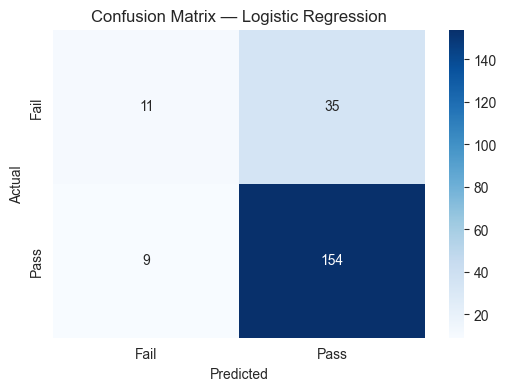

In [5]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Logistic Regression', y_test, y_pred))
models['Logistic Regression'] = ('scaled', lr)
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression', labels=target_labels)
plt.show()


  Decision Tree
  Accuracy    : 0.7943
  Precision   : 0.8409
  Recall      : 0.9080
  F1 Score    : 0.8732


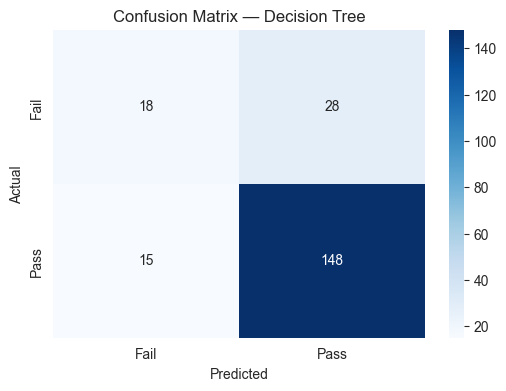

In [6]:
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_confusion_matrix(y_test, y_pred, 'Decision Tree', labels=target_labels)
plt.show()


  Random Forest
  Accuracy    : 0.7943
  Precision   : 0.8061
  Recall      : 0.9693
  F1 Score    : 0.8802


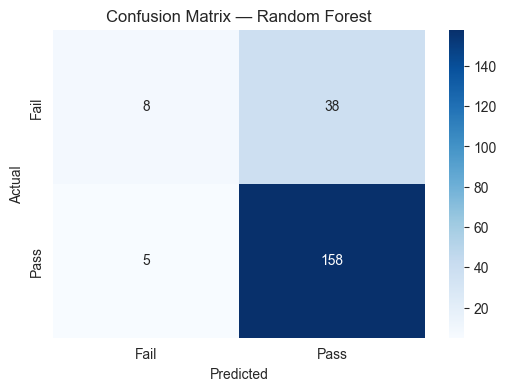

In [7]:
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_confusion_matrix(y_test, y_pred, 'Random Forest', labels=target_labels)
plt.show()

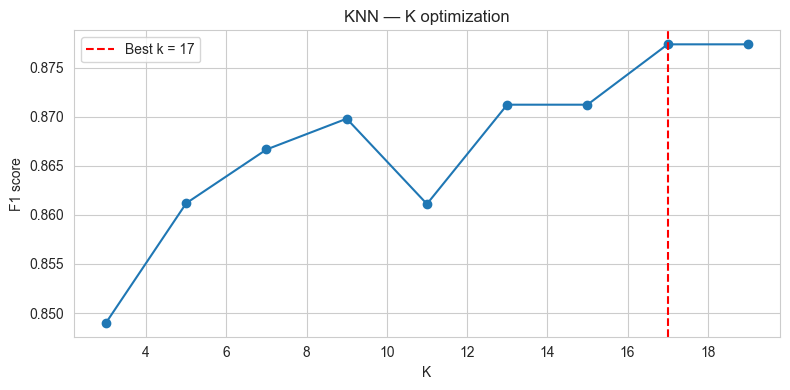


  KNN (k=17)
  Accuracy    : 0.7847
  Precision   : 0.7892
  Recall      : 0.9877
  F1 Score    : 0.8774


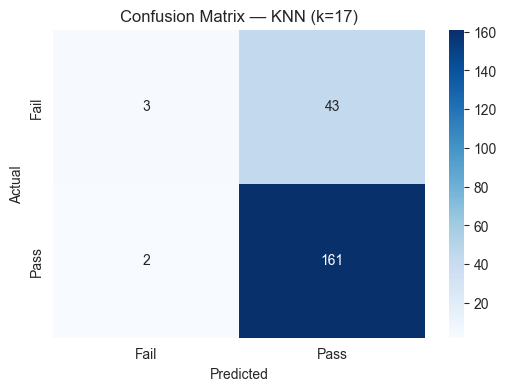

In [8]:
k_range = range(3, 21, 2)
k_scores = []
for k in k_range:
    knn_t = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(f1_score(y_test, knn_t.predict(X_test_scaled), zero_division=0))
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('K'); plt.ylabel('F1 score'); plt.title('KNN — K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_confusion_matrix(y_test, y_pred, knn_label, labels=target_labels)
plt.show()


  SVM
  Accuracy    : 0.7943
  Precision   : 0.8030
  Recall      : 0.9755
  F1 Score    : 0.8809


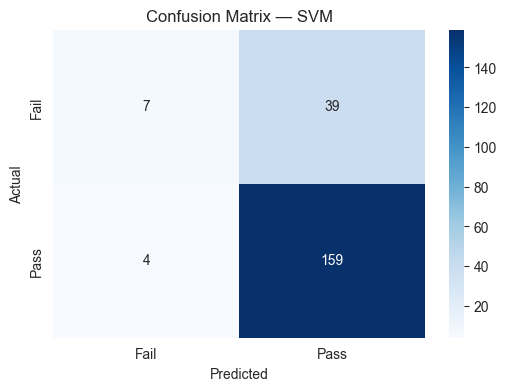

In [9]:
svm = SVC(probability=True, random_state=42, kernel='rbf')
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
results.append(evaluate_model('SVM', y_test, y_pred))
models['SVM'] = ('scaled', svm)
plot_confusion_matrix(y_test, y_pred, 'SVM', labels=target_labels)
plt.show()


  Gradient Boosting
  Accuracy    : 0.7943
  Precision   : 0.8191
  Recall      : 0.9448
  F1 Score    : 0.8775


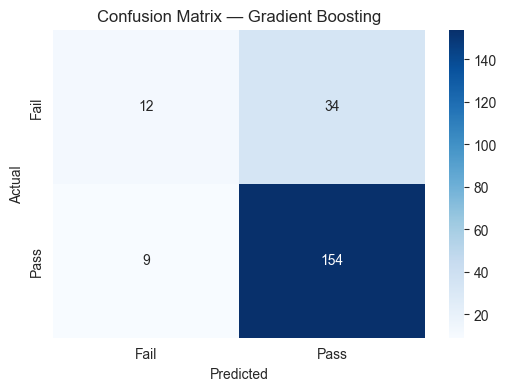

In [10]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_confusion_matrix(y_test, y_pred, 'Gradient Boosting', labels=target_labels)
plt.show()


  Naive Bayes
  Accuracy    : 0.7512
  Precision   : 0.8323
  Recall      : 0.8528
  F1 Score    : 0.8424


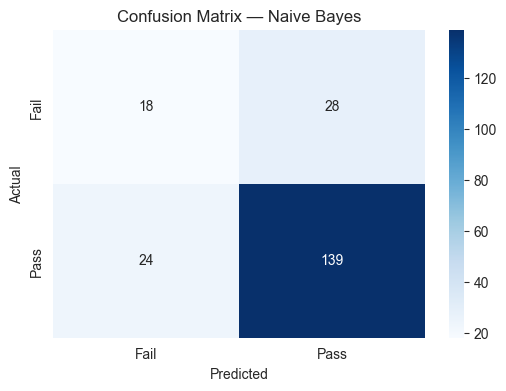

In [11]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)
y_pred = nb_clf.predict(X_test_scaled)
results.append(evaluate_model('Naive Bayes', y_test, y_pred))
models['Naive Bayes'] = ('scaled', nb_clf)
plot_confusion_matrix(y_test, y_pred, 'Naive Bayes', labels=target_labels)
plt.show()

## 4. Feature Importance — Tree Models

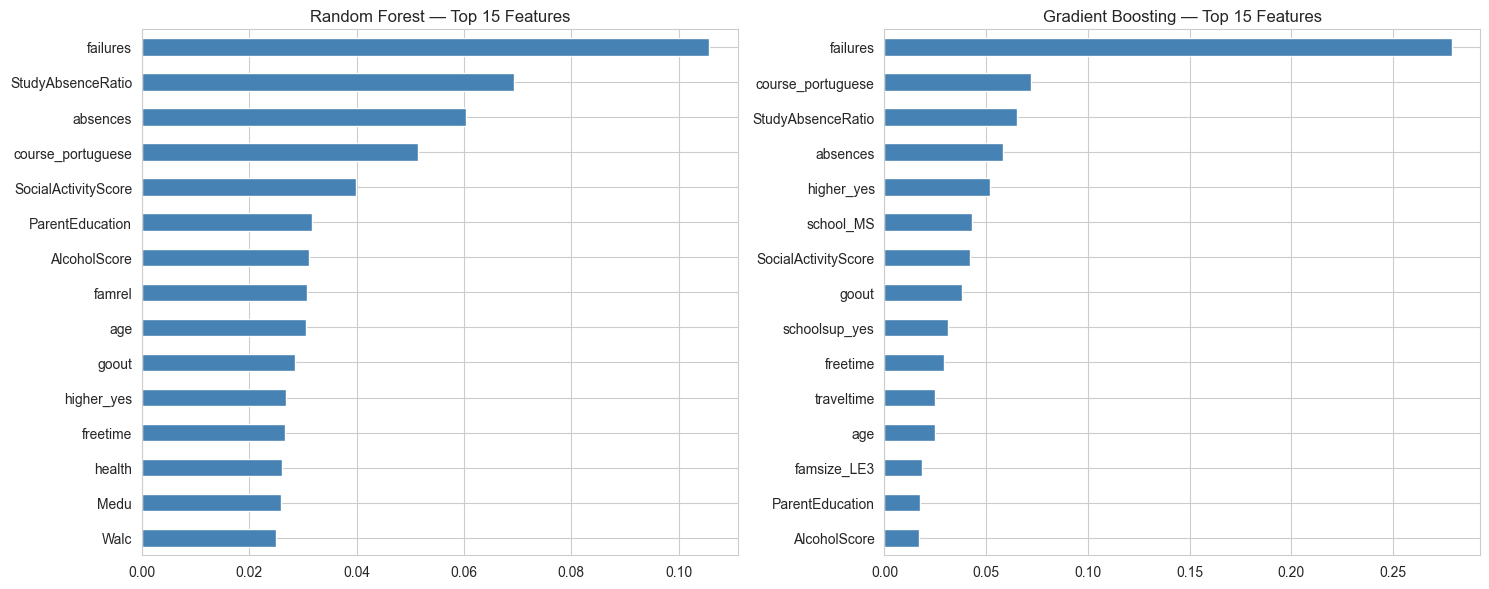

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout(); plt.show()

## 5. Model Comparison

In [13]:
comparison = compare_models(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.794258,0.803030,0.975460,0.880886
1,Random Forest,0.794258,0.806122,0.969325,0.880223
2,Gradient Boosting,0.794258,0.819149,0.944785,0.877493
3,KNN (k=17),0.784689,0.789216,0.987730,0.877384
4,Logistic Regression,0.789474,0.814815,0.944785,0.875000
5,Decision Tree,0.794258,0.840909,0.907975,0.873156
6,Naive Bayes,0.751196,0.832335,0.852761,0.842424


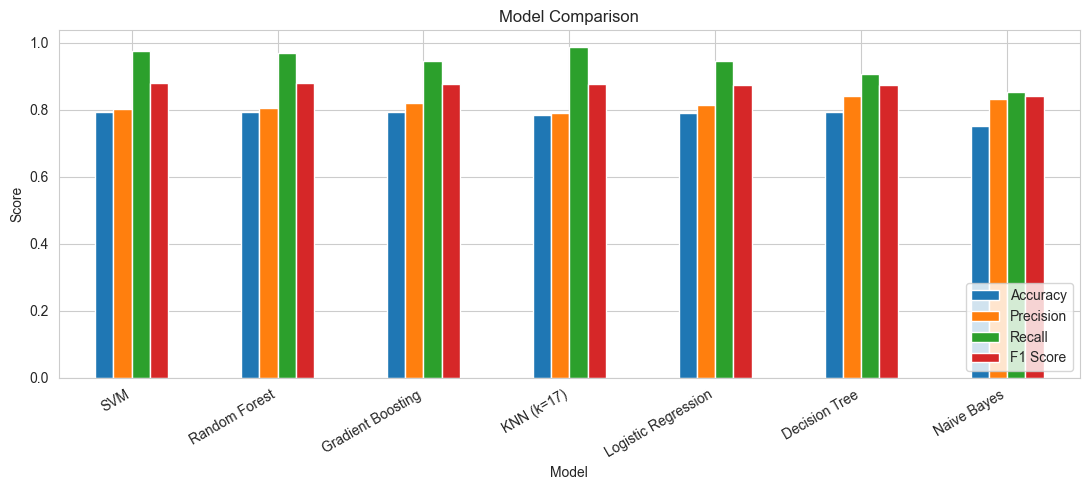

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison'); ax.set_ylabel('Score')
plt.xticks(rotation=30, ha='right'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 6. 5-Fold Cross-Validation

In [15]:
cv_scores = {}
X_full_scaled = scaler.fit_transform(X)
for name, (kind, model) in models.items():
    if kind == 'scaled':
        scores = cross_val_score(model, X_full_scaled, y, cv=5, scoring='f1', n_jobs=-1)
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean F1 = {scores.mean():.4f} (+/- {scores.std():.4f})')

Logistic Regression       mean F1 = 0.8433 (+/- 0.0364)


Decision Tree             mean F1 = 0.6129 (+/- 0.2863)


Random Forest             mean F1 = 0.8400 (+/- 0.0459)
KNN (k=17)                mean F1 = 0.8728 (+/- 0.0043)


SVM                       mean F1 = 0.8719 (+/- 0.0132)


Gradient Boosting         mean F1 = 0.6518 (+/- 0.2779)
Naive Bayes               mean F1 = 0.6994 (+/- 0.2829)


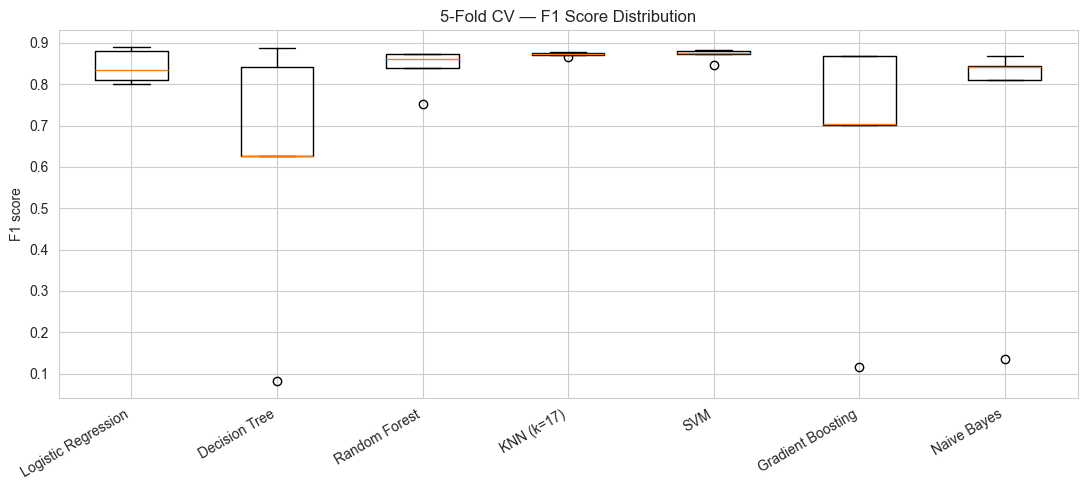

In [16]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('F1 score')
plt.title('5-Fold CV — F1 Score Distribution'); plt.tight_layout(); plt.show()

## 7. ROC Curves

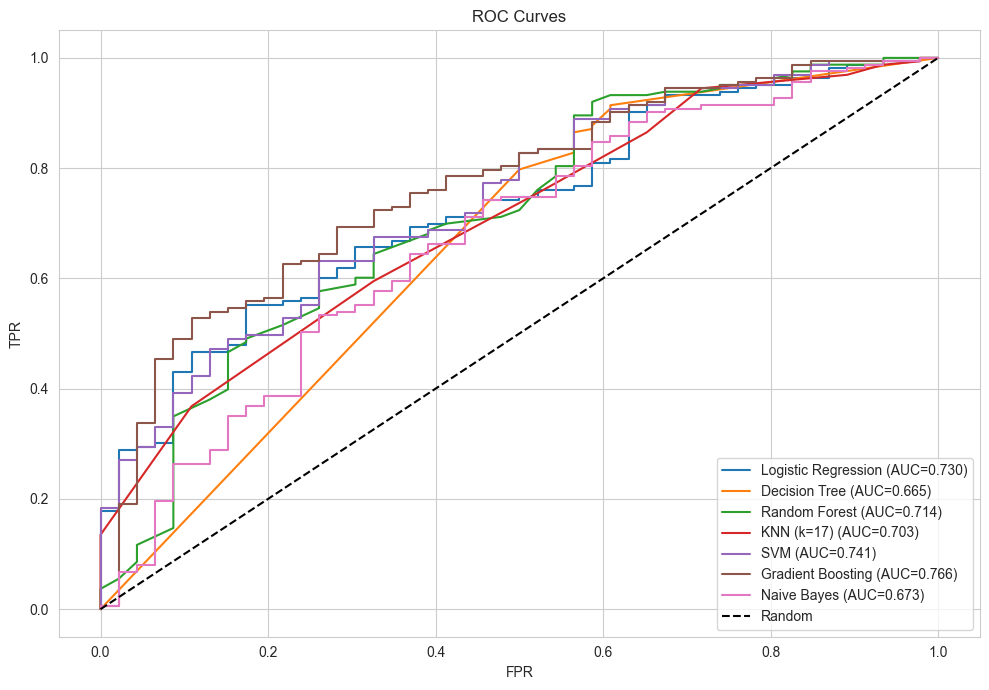

In [17]:
plt.figure(figsize=(10, 7))
for name, (kind, m) in models.items():
    Xt = X_test_scaled if kind == 'scaled' else X_test
    if hasattr(m, 'predict_proba'):
        yp = m.predict_proba(Xt)[:, 1]
    else:
        yp = m.decision_function(Xt)
    fpr, tpr, _ = roc_curve(y_test, yp)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 8. Hyperparameter Tuning — Best Performer

In [18]:
best_model_name = comparison.iloc[0]['Model']
print('Best model by F1:', best_model_name)

Best model by F1: SVM


Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1: 0.8843

  Random Forest (Tuned)
  Accuracy    : 0.7847
  Precision   : 0.7980
  Recall      : 0.9693
  F1 Score    : 0.8753


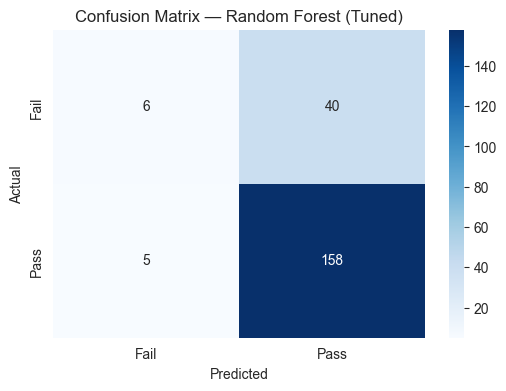

In [19]:
# Tune Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}
rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_tuned, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Random Forest (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_confusion_matrix(y_test, y_pred, 'Random Forest (Tuned)', labels=target_labels)
plt.show()

## 9. Tuned Model — Feature Importance

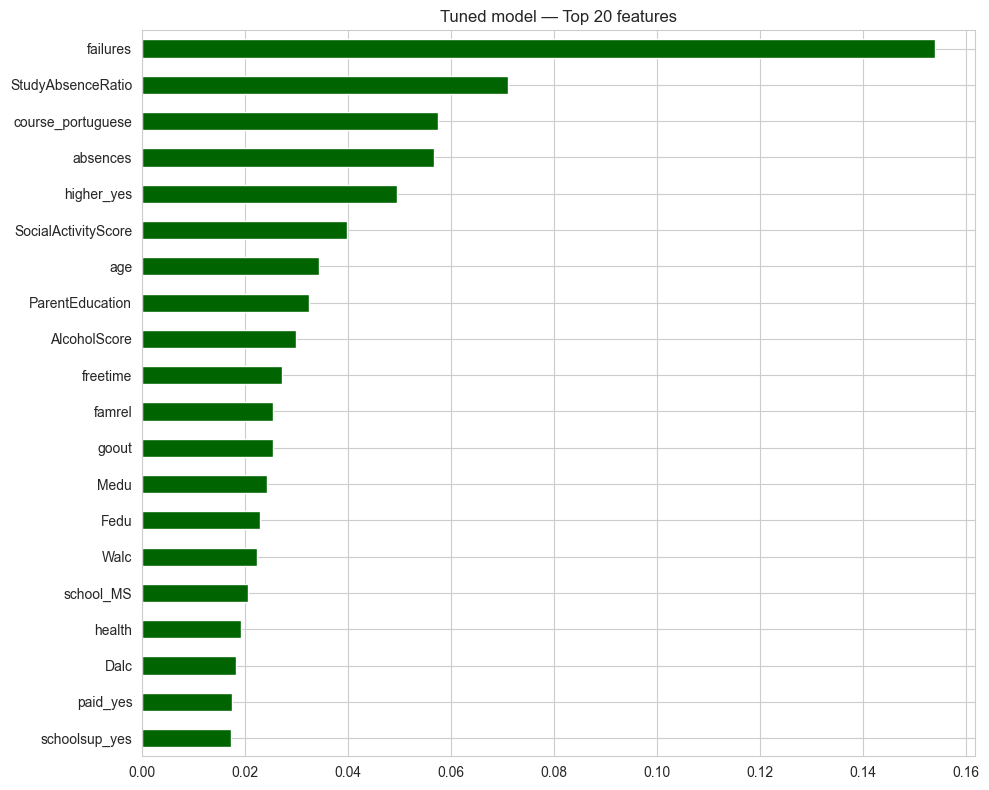

In [20]:
if hasattr(best, 'feature_importances_'):
    importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
    importances = pd.Series(np.abs(best.coef_[0]), index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 |coefficients|'); plt.tight_layout(); plt.show()

## 10. Sample Prediction

In [21]:
sample = X_test.iloc[:5].copy()
if 'best' in dir() and hasattr(best, 'predict'):
    preds = best.predict(sample)
    out = pd.DataFrame({'Predicted': preds, 'Actual': y_test.iloc[:5].values})
    if hasattr(best, 'predict_proba'):
        out['Probability'] = best.predict_proba(sample)[:, 1].round(3)
    print(out)
    out

   Predicted  Actual  Probability
0          1       1        0.828
1          1       1        0.746
2          1       1        0.924
3          1       0        0.838
4          1       1        0.799


## 11. Final Summary

In [22]:
final = compare_models(results)
final

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.794258,0.803030,0.975460,0.880886
1,Random Forest,0.794258,0.806122,0.969325,0.880223
2,Gradient Boosting,0.794258,0.819149,0.944785,0.877493
3,KNN (k=17),0.784689,0.789216,0.987730,0.877384
4,Random Forest (Tuned),0.784689,0.797980,0.969325,0.875346
5,Logistic Regression,0.789474,0.814815,0.944785,0.875000
6,Decision Tree,0.794258,0.840909,0.907975,0.873156
7,Naive Bayes,0.751196,0.832335,0.852761,0.842424


### Key Takeaways

- Student Pass/Fail Prediction: binary classification on `passed`.
- 7 classifiers + 1 tuned variant evaluated on accuracy / precision / recall / F1.
- Tree-based models highlight the most predictive features.
- ROC curves show discriminative power across thresholds.

### Next Steps

- Try class-weight balancing or SMOTE for imbalance.
- Test gradient boosters (XGBoost, LightGBM).
- Add probability calibration if scores are used downstream.
- Domain-specific feature engineering may further improve results.